# OSM roads 

This notebook downloads the roads (highway) from OpenStreetMap (OSM), filters the categories of interest, sort them by priority and then applies to each noise segment the first category which is within 5 m distance. 
It adds to the dataframe also the distance between the segment and the road, and the length of the segment.
Finally, it saves all the data into a csv.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [2]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Roads - OSM

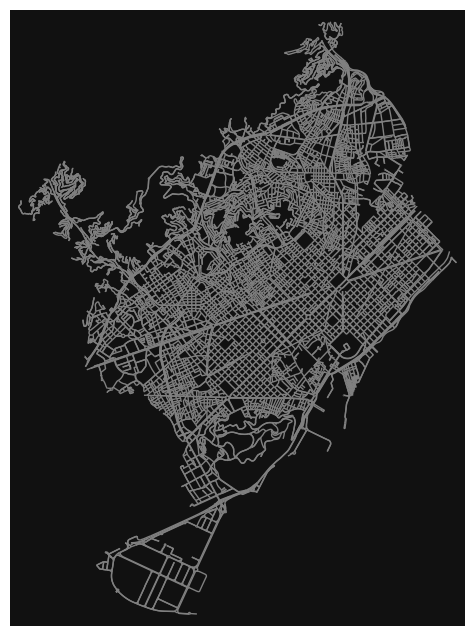

In [3]:
import osmnx as ox
#G = ox.graph_from_place("Barcelona, Spain", network_type="drive")
G = ox.load_graphml("data/barcelona.graphml")
ox.plot_graph(G, edge_color="gray", node_size=0)
ox.save_graphml(G, "barcelona.graphml")


## Prepare graph edges (roads)

In [4]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as noise_streets
roads = edges[edges.geometry.type == 'LineString'].to_crs(noise_streets.crs)
roads.to_file("bcn_osmnx_edges.gpkg", layer="edges", driver="GPKG")

## Check features completeness

In [5]:
print("Checking width..")
print(roads['width'].value_counts(dropna=False))
print("Checking maxspeed..")
print(roads['maxspeed'].value_counts(dropna=False))
print("Checking public_transport..")
print(roads['lanes'].value_counts(dropna=False))
print("Checking oneway..")
print(roads['oneway'].value_counts(dropna=False))

Checking width..
width
NaN                 14834
5                     207
6                     177
8                     154
9                     145
                    ...  
[7, 11]                 1
[6, 4.6]                1
[6, 15]                 1
9.6                     1
[3, 5, 4.8, 4.9]        1
Name: count, Length: 122, dtype: int64
Checking maxspeed..
maxspeed
30              9063
50              3892
20              1473
NaN              812
10               593
[20, 30]         316
80                98
[50, 30]          80
40                64
60                41
[10, 30]          29
[20, 10]          20
[50, 80]           8
[30, 40]           7
70                 5
[50, 40]           5
[50, 60]           4
[80, 60]           4
[50, 30, 40]       4
[20, 50]           3
[20, 10, 30]       3
[20, 50, 30]       3
4                  2
[70, 50]           2
[10, 15]           1
[50, 80, 60]       1
[20, 40]           1
[1, 30]            1
[70, 40]           1
[70, 80]      

## Check if road is tunnel

In [6]:
roads['is_tunnel'] = roads['tunnel'].fillna('no').eq('yes').astype(int)

## Filter roads categories

In [7]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 16541, Filtered: 15046


## Plot road categories distribution

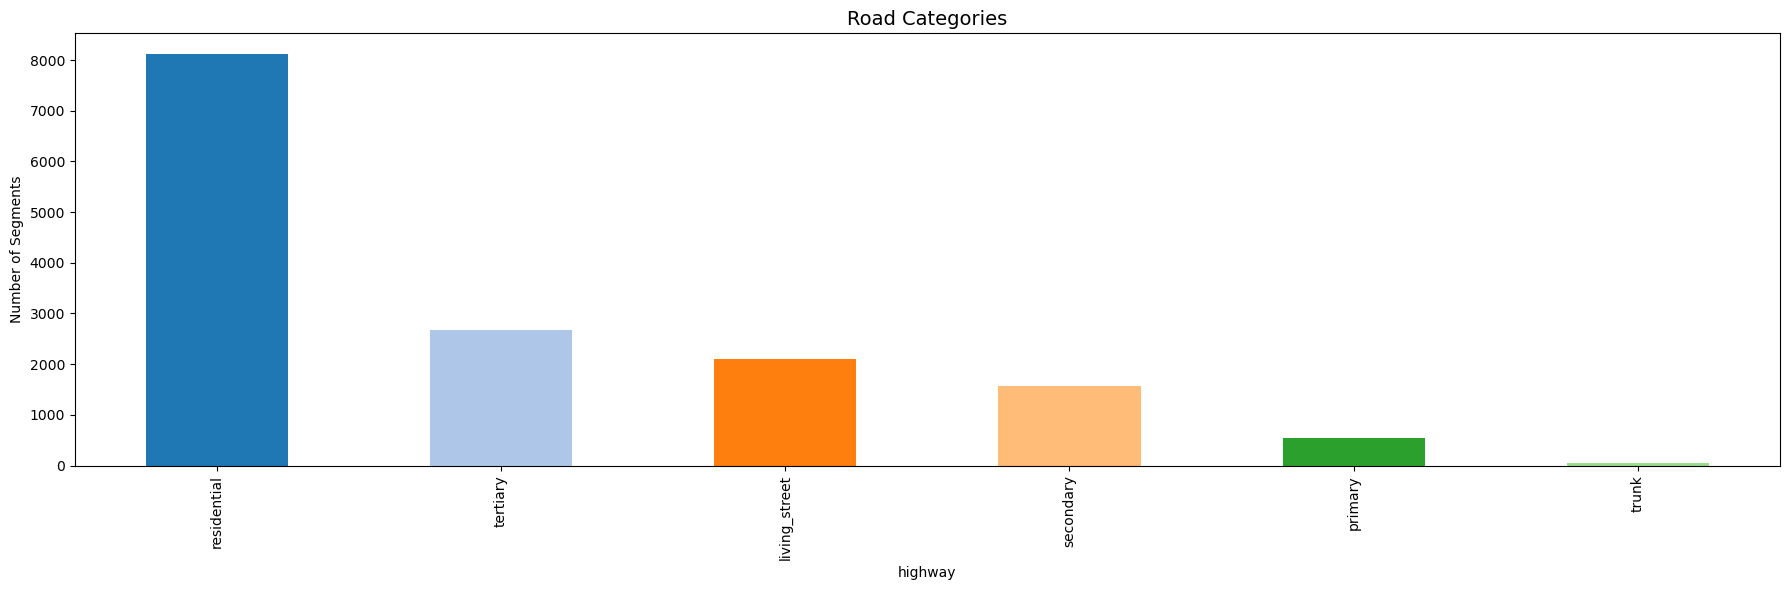

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


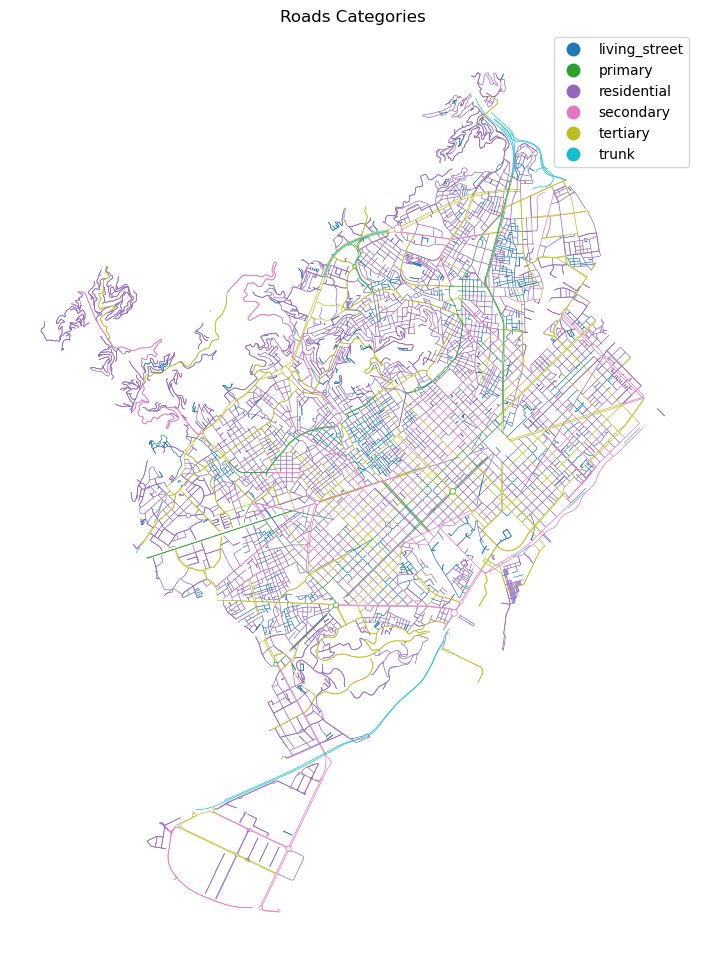

In [9]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign to each reoad segment the closest noise value

In [10]:
noise_roads = gpd.sjoin_nearest(roads_filtered, noise_streets, how='left',
                                 distance_col='distance')
noise_roads = noise_roads.dropna(subset=['TOTAL_D'])  # remove unmatched roads
noise_roads = noise_roads.sort_values('distance').loc[~noise_roads.index.duplicated(keep='first')]

print(f"Before: {len(roads_filtered)}, Merged: {len(noise_roads)}")

Before: 15046, Merged: 15046


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [11]:
# Classify noise dB string into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(range_str):
    if range_str == '< 40 dB(A)':
        val = 35
    else:
        val = int((range_str).split(' - ')[0])
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise('70 - 75 dB(A)'))  # expected: 4

4


In [12]:
noise_roads['noise_day'] = noise_roads['TOTAL_D'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['TOTAL_E'].apply(classify_noise)
noise_roads['noise_night'] = noise_roads['TOTAL_N'].apply(classify_noise)

noise_roads.head()

osmid        highway lanes  \
u           v           key                                                
21638868    30343649    0                   4079509       tertiary     2   
21638865    30343650    0                   4079505  living_street   NaN   
13859746868 13859746870 0                1518596110    residential     1   
21638917    190981834   0    [245672928, 246639229]      secondary     4   
                        0    [245672928, 246639229]      secondary     4   

                            maxspeed                        name  oneway  \
u           v           key                                                
21638868    30343649    0         30     Carrer de Pepe Rubianes   False   
21638865    30343650    0         20           Carrer del Judici    True   
13859746868 13859746870 0         30                         NaN    True   
21638917    190981834   0         50  Plaça del Portal de la Pau    True   
                        0         50  Plaça del Portal de la Pau    True   

                            reversed     length  \
u           v           key                       
21638868    30343649    0       True  15.060790   
21638865    30343650    0      False  15.466006   
13859746868 13859746870 0      False   7.674298   
21638917    190981834   0      False  30.695649   
                        0      False  30.695649   

                                                                      geometry  \
u           v           key                                                      
21638868    30343649    0    LINESTRING (432266.183 4581085.321, 432251.668...   
21638865    30343650    0    LINESTRING (432319.661 4580899.827, 432307.059...   
13859746868 13859746870 0    LINESTRING (428788.946 4586890.839, 428786.623...   
21638917    190981834   0    LINESTRING (431274.757 4580825.145, 431273.437...   
                        0    LINESTRING (431274.757 4580825.145, 431273.437...   

                            access  ...       OCI_N     PATIS_D     PATIS_E  \
u           v           key         ...                                       
21638868    30343649    0      NaN  ...  < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
21638865    30343650    0      NaN  ...  < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
13859746868 13859746870 0      NaN  ...  < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
21638917    190981834   0      NaN  ...  < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
                        0      NaN  ...  < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   

                            geometry_type   start     end distance noise_day  \
u           v           key                                                    
21638868    30343649    0            Line  432241  432265      0.0         2   
21638865    30343650    0            Line  432310  432319      0.0         1   
13859746868 13859746870 0            Line  428785  428722      0.0         3   
21638917    190981834   0            Line  431339  431264      0.0         4   
                        0            Line  431214  431264      0.0         3   

                             noise_evening  noise_night  
u           v           key                              
21638868    30343649    0                2            1  
21638865    30343650    0                1            0  
13859746868 13859746870 0                2            2  
21638917    190981834   0                4            3  
                        0                3            3  

[5 rows x 53 columns]

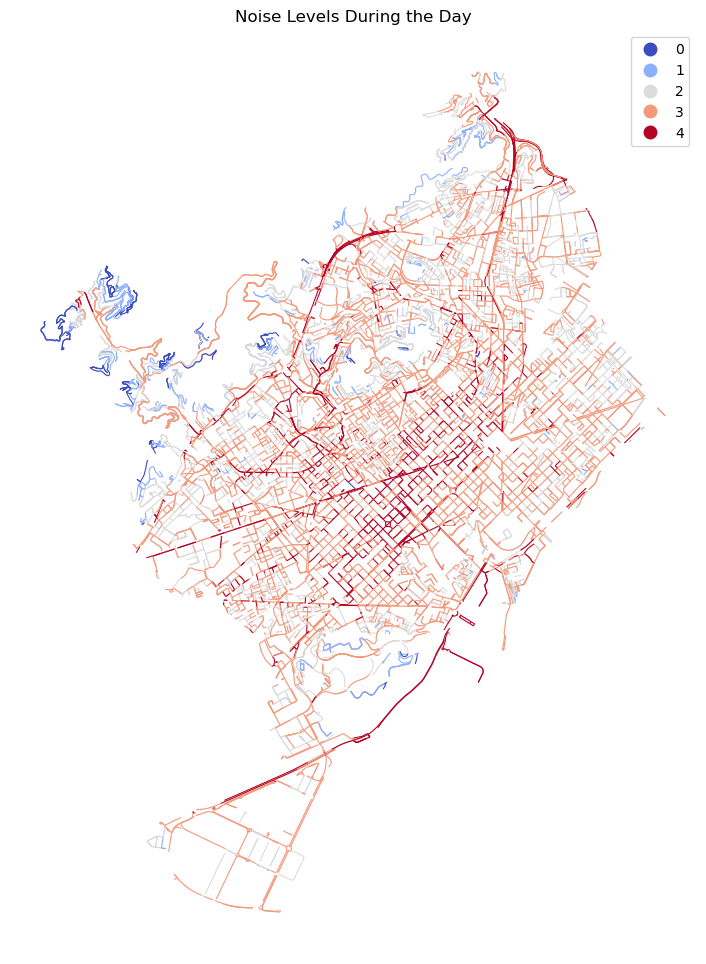

In [13]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day',categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Day')
ax.set_axis_off()

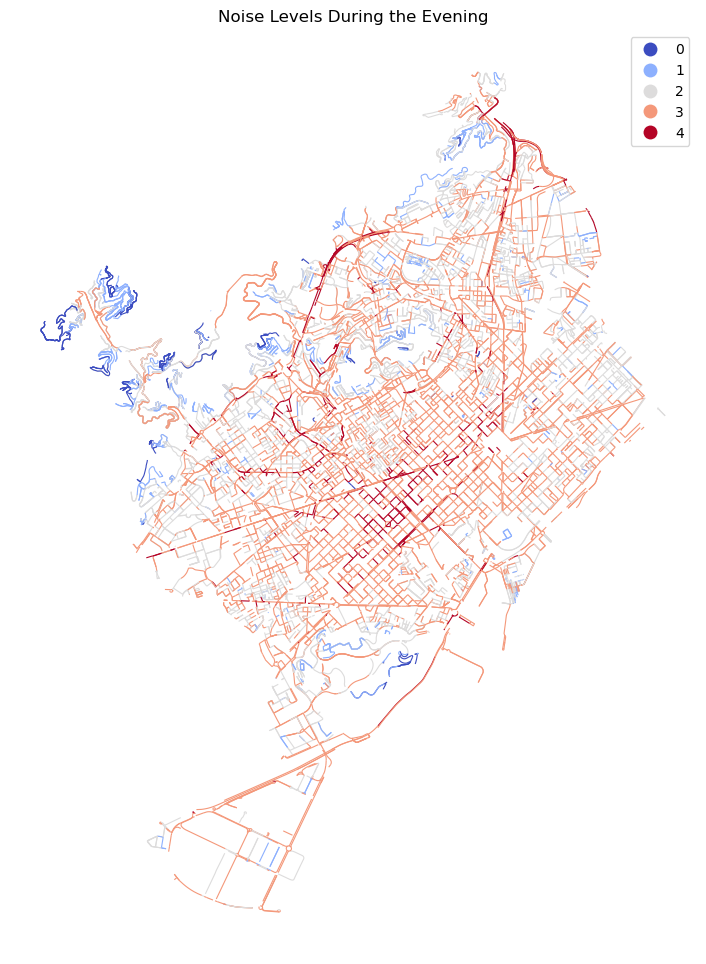

In [14]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Evening')
ax.set_axis_off()

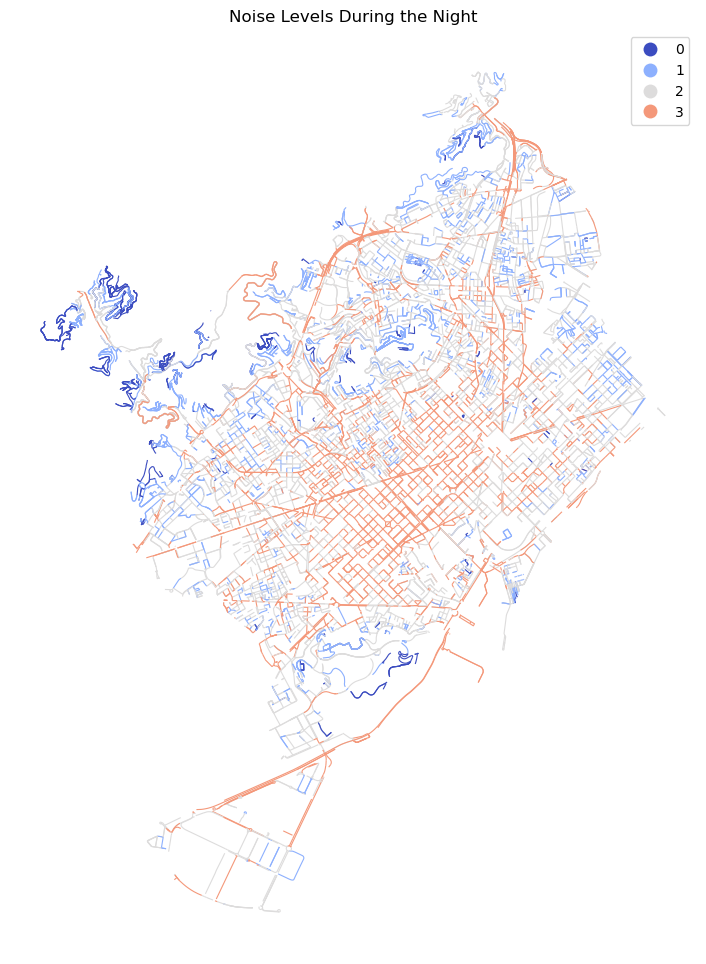

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Night')
ax.set_axis_off()

## Convert category to numerical feature

In [16]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      8321
tertiary         2498
living_street    2152
secondary        1476
primary           516
trunk              83
Name: count, dtype: int64

In [17]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

osmid        highway lanes  \
u           v           key                                                
21638868    30343649    0                   4079509       tertiary     2   
21638865    30343650    0                   4079505  living_street   NaN   
13859746868 13859746870 0                1518596110    residential     1   
21638917    190981834   0    [245672928, 246639229]      secondary     4   
                        0    [245672928, 246639229]      secondary     4   

                            maxspeed                        name  oneway  \
u           v           key                                                
21638868    30343649    0         30     Carrer de Pepe Rubianes   False   
21638865    30343650    0         20           Carrer del Judici    True   
13859746868 13859746870 0         30                         NaN    True   
21638917    190981834   0         50  Plaça del Portal de la Pau    True   
                        0         50  Plaça del Portal de la Pau    True   

                            reversed     length  \
u           v           key                       
21638868    30343649    0       True  15.060790   
21638865    30343650    0      False  15.466006   
13859746868 13859746870 0      False   7.674298   
21638917    190981834   0      False  30.695649   
                        0      False  30.695649   

                                                                      geometry  \
u           v           key                                                      
21638868    30343649    0    LINESTRING (432266.183 4581085.321, 432251.668...   
21638865    30343650    0    LINESTRING (432319.661 4580899.827, 432307.059...   
13859746868 13859746870 0    LINESTRING (428788.946 4586890.839, 428786.623...   
21638917    190981834   0    LINESTRING (431274.757 4580825.145, 431273.437...   
                        0    LINESTRING (431274.757 4580825.145, 431273.437...   

                            access  ...     PATIS_E geometry_type   start  \
u           v           key         ...                                     
21638868    30343649    0      NaN  ...  < 40 dB(A)          Line  432241   
21638865    30343650    0      NaN  ...  < 40 dB(A)          Line  432310   
13859746868 13859746870 0      NaN  ...  < 40 dB(A)          Line  428785   
21638917    190981834   0      NaN  ...  < 40 dB(A)          Line  431339   
                        0      NaN  ...  < 40 dB(A)          Line  431214   

                                end distance noise_day noise_evening  \
u           v           key                                            
21638868    30343649    0    432265      0.0         2             2   
21638865    30343650    0    432319      0.0         1             1   
13859746868 13859746870 0    428722      0.0         3             2   
21638917    190981834   0    431264      0.0         4             4   
                        0    431264      0.0         3             3   

                            noise_night  road_category  category_code  
u           v           key                                            
21638868    30343649    0             1       tertiary              4  
21638865    30343650    0             0  living_street              6  
13859746868 13859746870 0             2    residential              5  
21638917    190981834   0             3      secondary              3  
                        0             3      secondary              3  

[5 rows x 55 columns]

## Calculate distance to the closest road of each category

In [18]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,4079509,tertiary,2,30,Carrer de Pepe Rubianes,False,True,15.060790,"LINESTRING (432266.183 4581085.321, 432251.668...",NaN,...,2,1,tertiary,4,1462.932115,2131.092865,492.904878,0.000000,0.000000,0.000000
1,4079505,living_street,NaN,20,Carrer del Judici,True,False,15.466006,"LINESTRING (432319.661 4580899.827, 432307.059...",NaN,...,1,0,living_street,6,1420.227896,2300.048237,675.721286,192.974974,0.000000,0.000000
2,1518596110,residential,1,30,NaN,True,False,7.674298,"LINESTRING (428788.946 4586890.839, 428786.623...",NaN,...,2,2,residential,5,232.687902,502.124710,1111.341716,188.971039,0.000000,385.612798
3,"[245672928, 246639229]",secondary,4,50,Plaça del Portal de la Pau,True,False,30.695649,"LINESTRING (431274.757 4580825.145, 431273.437...",NaN,...,4,3,secondary,3,588.464995,1609.386075,0.000000,58.492257,162.714827,48.558225
5,"[293505299, 514849724]",tertiary,3,30,Pla de Palau,True,False,19.151231,"LINESTRING (431704.221 4581554.304, 431711.35 ...",NaN,...,3,3,tertiary,4,1432.029299,1409.121451,149.242081,0.000000,151.351124,184.454492


In [19]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,11711.000000,11711.000000,11711.000000,11711.000000,11711.000000,11711.000000
mean,1552.841185,793.593207,359.906130,139.206895,14.941923,158.153793
std,880.581424,810.043057,399.205312,161.973905,45.725352,277.277105
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,841.861443,231.753744,65.433865,0.000000,0.000000,0.000000
50%,1513.237747,556.537159,243.750844,98.565976,0.000000,81.675682
75%,2270.330929,1095.384601,518.925908,213.472208,0.000000,186.032610
max,3795.636971,4681.709946,2577.191528,1060.917082,758.291840,2415.828166


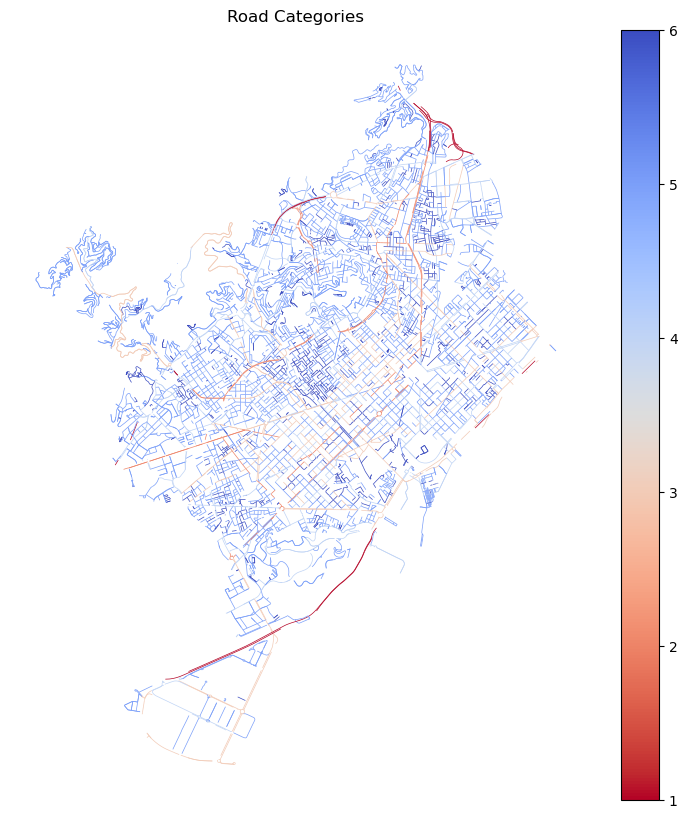

In [20]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [21]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,4079509,tertiary,2,30,Carrer de Pepe Rubianes,False,True,15.060790,"LINESTRING (432266.183 4581085.321, 432251.668...",NaN,...,2,1,tertiary,4,1462.932115,2131.092865,492.904878,0.000000,0.000000,0.000000
1,4079505,living_street,NaN,20,Carrer del Judici,True,False,15.466006,"LINESTRING (432319.661 4580899.827, 432307.059...",NaN,...,1,0,living_street,6,1420.227896,2300.048237,675.721286,192.974974,0.000000,0.000000
2,1518596110,residential,1,30,NaN,True,False,7.674298,"LINESTRING (428788.946 4586890.839, 428786.623...",NaN,...,2,2,residential,5,232.687902,502.124710,1111.341716,188.971039,0.000000,385.612798
3,"[245672928, 246639229]",secondary,4,50,Plaça del Portal de la Pau,True,False,30.695649,"LINESTRING (431274.757 4580825.145, 431273.437...",NaN,...,4,3,secondary,3,588.464995,1609.386075,0.000000,58.492257,162.714827,48.558225
5,"[293505299, 514849724]",tertiary,3,30,Pla de Palau,True,False,19.151231,"LINESTRING (431704.221 4581554.304, 431711.35 ...",NaN,...,3,3,tertiary,4,1432.029299,1409.121451,149.242081,0.000000,151.351124,184.454492


## Create data frame

In [22]:
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]

dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'],
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{col: noise_roads[col] for col in distance_cols},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,21638868_30343649_0,2,2,1,4,1462.932115,2131.092865,492.904878,0.000000,0.000000,0.000000
1,21638865_30343650_0,1,1,0,6,1420.227896,2300.048237,675.721286,192.974974,0.000000,0.000000
2,13859746868_13859746870_0,3,2,2,5,232.687902,502.124710,1111.341716,188.971039,0.000000,385.612798
3,21638917_190981834_0,4,4,3,3,588.464995,1609.386075,0.000000,58.492257,162.714827,48.558225
5,21638891_190971702_0,3,3,3,4,1432.029299,1409.121451,149.242081,0.000000,151.351124,184.454492


## Export dataset to CSV

In [23]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported roads_noise_class.csv")

Exported roads_noise_class.csv
